# Введение в машинное обучение и практические задания с использованием набора инструментов

# Что такое машинное обучение?

| Это | —   |
|------|------|
|   Машинное обучение позволяет компьютерам учиться и делать выводы на основе данных.  | ![robot.png](Assets/robot.png)|




# Цели обучения

- Продемонстрировать алгоритмы обучения с учителем
- Объяснить ключевые понятия, такие как недообучение и переобучение, регуляризация и перекрестная валидация
- Определить тип решаемой задачи, выбрать подходящий алгоритм, настроить параметры и проверить модель
- Применять расширение Intel® для Scikit-learn*, чтобы использовать вычислительные возможности аппаратного обеспечения


# Обзор курса:

### Темы курса:

- Введение и эксплораторный анализ (1-я неделя)
- Управляемое машинное обучение (2–10-я недели)
- Безуправляемое машинное обучение (недели 11–12)

### Требования к слушателям:

- Программирование на Python*
- Математический анализ
- Линейная алгебра
- Статистика

### Набор инструментов: Intel® oneAPI AI Analytics Toolkit (AI Kit)
- Intel® Extension for Scikit-learn*



## Введение

В этом учебном пособии мы будем использовать набор данных «Iris». Это хорошо известный набор данных, содержащий сведения о видах ирисов, а также измерения чашелистиков и лепестков. Данные, которые мы будем использовать, находятся в файле `Iris_Data.csv`, расположенном в каталоге [data](../../data).

In [ ]:
from __future__ import print_function
import os
data_path = [ 'data']

# Intel® oneAPI Toolkits Installation
The [following documents](https://software.intel.com/content/www/us/en/develop/articles/installation-guide-for-intel-oneapi-toolkits.html) provide detailed instructions on how to get and install Intel® oneAPI packages using different installer modes and package managers:

- [Intel® oneAPI Toolkits Installation Guide for Linux* OS](https://software.intel.com/content/www/us/en/develop/documentation/installation-guide-for-intel-oneapi-toolkits-linux/top.html)
- [Intel® oneAPI Toolkits Installation Guide for Windows*](https://software.intel.com/content/www/us/en/develop/documentation/installation-guide-for-intel-oneapi-toolkits-windows/top.html)
- [Intel® oneAPI Toolkits Installation Guide for macOS*](https://software.intel.com/content/www/us/en/develop/documentation/installation-guide-for-intel-oneapi-toolkits-macos/top.html)



# scikit-learn*

Frameworks provide structure that Data Scientists use to build code. Frameworks are more than just libraries, because in addition to callable code, frameworks influence how code is written.

A main virtue of using an optimized framework is that code runs faster. Code that runs faster is just generally more convenient but when we begin looking at applied data science and AI models, we can see more material benefits. Here you will see how optimization, particularly hyperparameter optimization can benefit more than just speed.

These exercises will demonstrate how to apply **the Intel® Extension for Scikit-learn*,** a seamless way to speed up your Scikit-learn application. The acceleration is achieved through the use of the Intel® oneAPI Data Analytics Library (oneDAL). Patching is the term used to extend scikit-learn with Intel optimizations and makes it a well-suited machine learning framework for dealing with real-life problems.

To get optimized versions of many Scikit-learn algorithms using a patch() approach consisting of adding these lines of code after importing sklearn:

- **from sklearnex import patch_sklearn**
- **patch_sklearn()**


## Вопрос 1

Загрузите данные из файла, используя методы, изученные сегодня. Проанализируйте их.

Определите следующее:

* Количество точек данных (строк). (*Подсказка:* проверьте атрибут `.shape` датафрейма.)
* Названия столбцов. (*Подсказка:* проверьте атрибут `.columns` датафрейма.)
* Типы данных для каждого столбца. (*Подсказка:* проверьте атрибут `.dtypes` датафрейма.)

In [ ]:
import numpy as np
import pandas as pd

filepath = os.sep.join(data_path + ['Iris_Data.csv'])
data = pd.read_csv(filepath)
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Number of rows
print(data.shape[0])

# Column names
print(data.columns.tolist())

# Data types
print(data.dtypes)

150
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


## Вопрос 2

Проанализируйте названия видов и обратите внимание, что все они начинаются с «Iris-». Удалите эту часть названия, чтобы название вида стало короче.

*Подсказка:* сделать это можно несколькими способами, но вы можете использовать либо [методы обработки строк](http://pandas.pydata.org/pandas-docs/stable/text.html), либо [метод apply](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.apply.html).

In [ ]:
# The str method maps the following function to each entry as a string
data['species'] = data.species.str.replace('Iris-', '')
# alternatively
# data['species'] = data.species.apply(lambda r: r.replace('Iris-', ''))

data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Вопрос 3

Определите следующее:
* Количество особей каждого вида. (*Подсказка:* ознакомьтесь с методом `.value_counts`.)
* Среднее значение, медиану, квантили и диапазоны (максимум–минимум) для каждого измерения лепестков и чашелистиков.

*Подсказка:* в последнем вопросе метод `.describe` действительно содержит медиану, но она называется не «медиана», а *50%* квантиль. Однако метод `.describe` не возвращает диапазон, и чтобы получить его, вам нужно будет создать новую строку в таблице `.describe` со значением `max - min`.

In [ ]:
# One way to count each species
data.species.value_counts()

virginica     50
setosa        50
versicolor    50
Name: species, dtype: int64

In [ ]:
# Select just the rows desired from the 'describe' method and add in the 'median'
stats_df = data.describe()
stats_df = data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['mean','25%','50%','75%', 'range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df

,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000
range,3.600000,2.400,5.900000,2.400000


## Вопрос 4

Рассчитайте следующие показатели **для каждого вида** в отдельном датафрейме:

* Среднее значение каждого измерения (sepal_length, sepal_width, petal_length и petal_width).
* Медиана каждого из этих измерений.

*Подсказка:* перед вычислением статистических показателей можно использовать метод [`groupby`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html) библиотеки Pandas для группировки по видам.

Если вы выполнили оба этих задания, попробуйте вычислить обе статистические величины (среднее и медиану) в одной таблице (т. е. с помощью одного вызова `groupby`). Подсказку см. в разделе документации Pandas, посвящённом [одновременному применению нескольких функций](http://pandas.pydata.org/pandas-docs/stable/groupby.html#applying-multiple-functions-at-once).

In [ ]:
# The mean calculation
data.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [ ]:
# The median calculation
data.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


In [ ]:
# applying multiple functions at once - 2 methods

data.groupby('species').agg(['mean', 'median'])  # passing a list of recognized strings
data.groupby('species').agg([np.mean, np.median])  # passing a list of explicit aggregation functions

sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

In [ ]:
# If certain fields need to be aggregated differently, we can do:
from pprint import pprint

agg_dict = {field: ['mean', 'median'] for field in data.columns if field != 'species'}
agg_dict['petal_length'] = 'max'
pprint(agg_dict)
data.groupby('species').agg(agg_dict)

{'petal_length': 'max',
 'petal_width': ['mean', 'median'],
 'sepal_length': ['mean', 'median'],
 'sepal_width': ['mean', 'median']}


sepal_length        sepal_width        petal_length petal_width  \
                   mean median        mean median          max        mean   
species                                                                      
setosa            5.006    5.0       3.418    3.4          1.9       0.244   
versicolor        5.936    5.9       2.770    2.8          5.1       1.326   
virginica         6.588    6.5       2.974    3.0          6.9       2.026   

                   
           median  
species            
setosa        0.2  
versicolor    1.3  
virginica     2.0

## Вопрос 5

Постройте точечный график зависимости `sepal_length` от `sepal_width` с помощью Matplotlib. Обозначьте оси и дайте графику название.

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

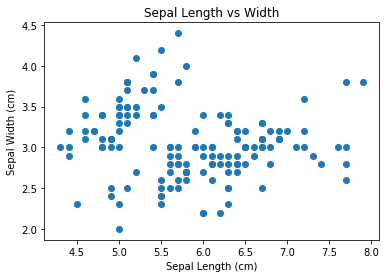

In [ ]:
# A simple scatter plot with Matplotlib
ax = plt.axes()

ax.scatter(data.sepal_length, data.sepal_width)

# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');

## Вопрос 6

Постройте гистограмму по любому из четырёх показателей. Обозначьте оси и дайте гистограмме соответствующее название.

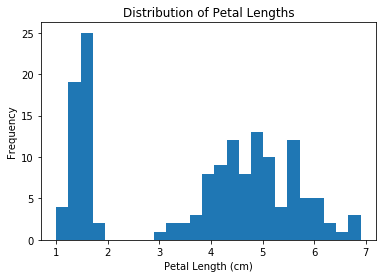

In [ ]:
# Using Matplotlib's plotting functionality
ax = plt.axes()
ax.hist(data.petal_length, bins=25);

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

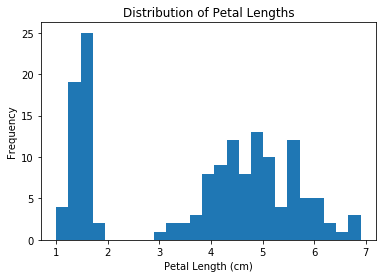

In [ ]:
# Alternatively using Pandas plotting functionality
ax = data.petal_length.plot.hist(bins=25)

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

## Вопрос 7

Теперь создайте один график, на котором будут наложены гистограммы по каждому признаку (`petal_width`, `petal_length`, `sepal_width`, `sepal_length`). Если у вас есть время, попробуйте затем создать четыре отдельных графика гистограмм на одном рисунке, где каждый график будет отображать один признак.

Некоторые подсказки о том, как это сделать с помощью методов построения графиков Pandas, вы найдёте в [руководстве по визуализации](http://pandas.pydata.org/pandas-docs/version/0.18.1/visualization.html) для Pandas.

In [ ]:
try:
    import seaborn as sns

except:
    print('Seaborn must be installed for this course. Execute the following:')
    print('`conda install seaborn`')
    print('from a terminal and restart the kernel.')

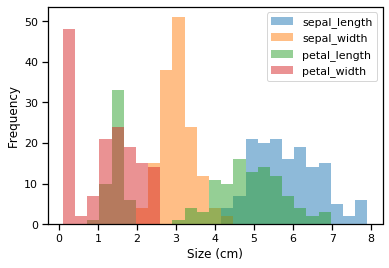

In [ ]:
sns.set_context('notebook')

# This uses the `.plot.hist` method
ax = data.plot.hist(bins=25, alpha=0.5)
ax.set_xlabel('Size (cm)');

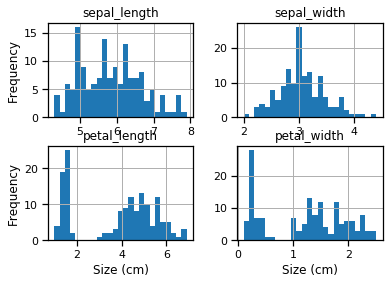

In [ ]:
# To create four separate plots, use Pandas `.hist` method
axList = data.hist(bins=25)

# Add some x- and y- labels to first column and last row
for ax in axList.flatten():
    if ax.is_last_row():
        ax.set_xlabel('Size (cm)')

    if ax.is_first_col():
        ax.set_ylabel('Frequency')

## Вопрос 8

С помощью Pandas постройте бокс-плат для каждого измерения лепестков и чашелистиков. Вот документация по [методу boxplot в Pandas](http://pandas.pydata.org/pandas-docs/version/0.18.1/visualization.html#visualization-box).

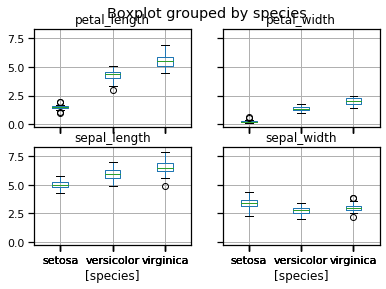

In [ ]:
# Pandas plotting functionality is pretty awesome!
# Here we have four separate plots

data.boxplot(by='species');

## Вопрос 9

Теперь постройте один бокс-плат, в котором признаки будут разделены по оси x, а виды будут выделены разными оттенками.

*Подсказка:* рекомендуется ознакомиться с документацией по [бокс-платам Seaborn](http://seaborn.pydata.org/generated/seaborn.boxplot.html).

Также обратите внимание, что Seaborn очень требователен к формату данных — чтобы этот график сработал, исходный датафрейм необходимо обработать таким образом, чтобы каждая строка содержала одну точку данных (вид, тип измерения и значение измерения). В качестве отправной точки ознакомьтесь с методом [stack](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.stack.html) в Pandas.

Вот пример формата данных, который подойдет:
|   | species | measurement  | size |
| - | ------- | ------------ | ---- |
| 0	| setosa  | sepal_length | 5.1  |
| 1	| setosa  | sepal_width  | 3.5  |

In [ ]:
# First we have to reshape the data so there is
# only a single measurement in each column

plot_data = (data
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()

,species,measurement,size
0,setosa,sepal_length,5.1
1,setosa,sepal_width,3.5
2,setosa,petal_length,1.4
3,setosa,petal_width,0.2
4,setosa,sepal_length,4.9


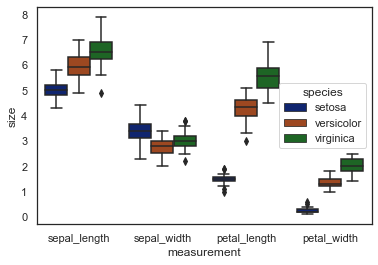

In [ ]:
# Now plot the dataframe from above using Seaborn

sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size',
            hue='species', data=plot_data);

## Вопрос 10

Создайте [pairplot](http://seaborn.pydata.org/generated/seaborn.pairplot.html) с помощью Seaborn, чтобы проанализировать корреляцию между каждыми из измерений.

*Подсказка:* этот график может показаться сложным, но на самом деле он состоит всего из одной строки кода. В этом и заключается сила Seaborn и построения графиков с поддержкой dataframe! См. конспект лекции для справки.

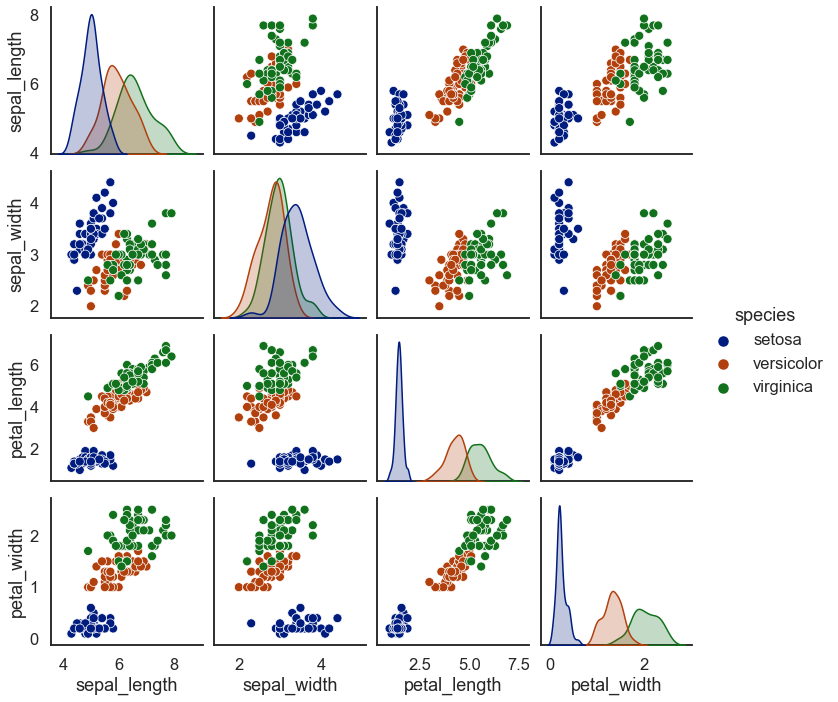

In [ ]:
sns.set_context('talk')
sns.pairplot(data, hue='species');